# Feature Engineering Using Scikit-Learn

### Do You Want to Build a Snowman?

Prepare the inputs for a model that predicts snowman height.

<img src="../assets/olaf.jpeg" width="300" alt="Snowman illustration">

This deliberately tiny, fictional dataset is a **preprocessing exercise**, not evidence that lunch or dinner predicts snowman height. Treat all rows as a supplied training sample; do not report a model generalization score from these 14 examples.

**Business connection:** in a housing dataset, the same steps could impute missing floor areas, scale numerical measurements, and encode property types before predicting price. The workflow transfers; the useful features and preprocessing choices depend on the task.

#### Load Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#### Load Data

In [2]:
data = {
    "temp": [-3, 5, 0, 7, 3, -1, 1, None, -6, 3, 0, -1, None, -2],
    "lunch": [
        "soup",
        "sandwich",
        "soup",
        "burger",
        "sandwich",
        "soup",
        "cereal",
        "salad",
        "sandwich",
        "burger",
        "soup",
        "cereal",
        "burger",
        "soup",
    ],
    "dinner": [
        "pizza",
        "pizza",
        "noodles",
        None,
        "fishsticks",
        "pizza",
        None,
        "fishsticks",
        "noodles",
        "pizza",
        None,
        "pizza",
        "fishsticks",
        "pizza",
    ],
    "precipitation": [
        "yes",
        "no",
        "yes",
        "yes",
        "yes",
        "yes",
        "no",
        "yes",
        "yes",
        "no",
        "yes",
        "yes",
        "yes",
        "no",
    ],
    "height_snowman_cm": [100, 0, 75, 0, 20, 25, 0, 35, 170, 0, 85, 85, 45, 0],
}

df_train = pd.DataFrame(data=data).fillna(np.nan)
df_train

,temp,lunch,dinner,precipitation,height_snowman_cm
0,-3.0,soup,pizza,yes,100
1,5.0,sandwich,pizza,no,0
2,0.0,soup,noodles,yes,75
3,7.0,burger,NaN,yes,0
4,3.0,sandwich,fishsticks,yes,20
5,-1.0,soup,pizza,yes,25
6,1.0,cereal,NaN,no,0
7,NaN,salad,fishsticks,yes,35
8,-6.0,sandwich,noodles,yes,170
9,3.0,burger,pizza,no,0


## One Possible Solution

1. Separate `df_train` into `X_train` and `y_train`; the target is `height_snowman_cm`.
2. Identify numeric, nominal, and binary inputs, then inspect missing values.
3. Impute `temp` with its training median and `dinner` with its most frequent value. Row order has no time meaning here, so do not interpolate between unrelated observations.
4. Scale `temp` and one-hot encode `lunch`, `dinner`, and `precipitation`.
5. Use the tools imported above: `SimpleImputer`, `StandardScaler`, and `OneHotEncoder`. Combine the transformed DataFrames with `pd.concat(axis=1)`.
6. Produce `X_train_fe` with numerical values, no missing values, the same row count and index as `X_train`, and no target column.

These are example choices, not the only valid answer: explain why your transformations suit each variable. Fit on training data only. To transform new rows later, reuse the fitted objects instead of recomputing statistics.

1. **Separate the DataFrame `df_train` into `X_train` and `y_train`**

In [3]:
target = "height_snowman_cm"

In [4]:
# Feature matrix
X_train = df_train.drop(target, axis=1)
y_train = df_train[target]

In [5]:
X_train.columns

Index(['temp', 'lunch', 'dinner', 'precipitation'], dtype='str')

2.1 **Identify which variables are binary, categorical and  numeric**

| Column Name | Type     |
|----------|----------------|
| temp       |numeric   |
| lunch        | categorical nominal|
| dinner        | categorical nominal|
| precipitation        | categorical binary|


2.2 **Check which variables have missing values**

In [6]:
X_train.isna().sum()

temp             2
lunch            0
dinner           3
precipitation    0
dtype: int64

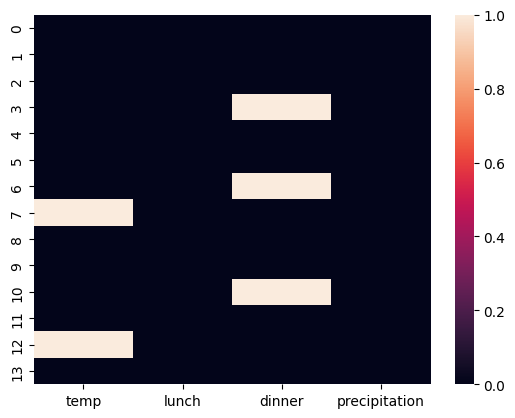

In [7]:
sns.heatmap(data=X_train.isna());

The variables `temp` and `dinner` contain missing values at observations 7 and 12 for `temp`, and at observations 3, 6, and 10 for `dinner`, respectively.

2.3 **Impute missing values**

**Numeric Variable `temp`**

Use a median learned on the training sample. Unlike interpolation across rows, this transformation gives the same result for a new observation regardless of its position in a batch.

In [8]:
temp_imputer = SimpleImputer(strategy="median").set_output(transform="pandas")

In [9]:
temp_imputer.fit(X_train[["temp"]])

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['temp']
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](1,)",[0.]


In [10]:
temp_imputed_train = temp_imputer.transform(X_train[["temp"]])
temp_imputed_train

,temp
0,-3.0
1,5.0
2,0.0
3,7.0
4,3.0
5,-1.0
6,1.0
7,0.0
8,-6.0
9,3.0


In [11]:
temp_scaler = StandardScaler().set_output(transform="pandas")

In [12]:
temp_scaled_train = temp_scaler.fit_transform(temp_imputed_train)
temp_scaled_train

,temp
0,-1.078720
1,1.438293
2,-0.134840
3,2.067546
4,0.809040
5,-0.449467
6,0.179787
7,-0.134840
8,-2.022600
9,0.809040


**Nominal Variable `dinner`**

We can fill the missing value by using as strategy the most frequent category

In [13]:
dinner_imputer = SimpleImputer(
    strategy="most_frequent",
).set_output(transform="pandas")

In [14]:
dinner_imputer.fit(X_train[["dinner"]])

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['dinner']
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[object](1,)",['pizza']


In [15]:
dinner_imputed_train = dinner_imputer.transform(X_train[["dinner"]])
dinner_imputed_train

,dinner
0,pizza
1,pizza
2,noodles
3,pizza
4,fishsticks
5,pizza
6,pizza
7,fishsticks
8,noodles
9,pizza


2.4 **Encode Categorical variables**

**`lunch` and `precipitation`**

In [16]:
subset_categoric = ["lunch", "precipitation"]

In [17]:
ohe_encoder = OneHotEncoder(sparse_output=False, drop="first").set_output(
    transform="pandas"
)

In [18]:
ohe_encoder.fit(X_train[subset_categoric])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreq

In [19]:
lunch_prep_encoded_train = ohe_encoder.transform(X_train[subset_categoric])
lunch_prep_encoded_train

,lunch_cereal,lunch_salad,lunch_sandwich,lunch_soup,precipitation_yes
0,0.0,0.0,0.0,1.0,1.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,1.0
3,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,1.0
5,0.0,0.0,0.0,1.0,1.0
6,1.0,0.0,0.0,0.0,0.0
7,0.0,1.0,0.0,0.0,1.0
8,0.0,0.0,1.0,0.0,1.0
9,0.0,0.0,0.0,0.0,0.0


**`encoding dinner`**

In [20]:
dinner_encoder = OneHotEncoder(sparse_output=False, drop="first").set_output(
    transform="pandas"
)

In [21]:
dinner_encoder.fit(dinner_imputed_train[["dinner"]])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreq

The dinner encoder receives the **imputed dinner column**. The lunch and precipitation encoder handles the other categorical inputs. No feature is duplicated.

This solution uses `drop="first"`, keeping one fewer indicator per categorical input. The advanced solution keeps all indicators, so their output column counts differ intentionally. Both are valid preprocessing choices here. These introductory encoders use the default `handle_unknown="error"`: a new category raises an error rather than silently becoming the reference category.

In [22]:
dinner_encoded_train = dinner_encoder.transform(dinner_imputed_train[["dinner"]])
dinner_encoded_train

,dinner_noodles,dinner_pizza
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,0.0,1.0
4,0.0,0.0
5,0.0,1.0
6,0.0,1.0
7,0.0,0.0
8,1.0,0.0
9,0.0,1.0


3. **Create X_train_fe**

In [23]:
transformed_dataframes = [
    temp_scaled_train,
    dinner_encoded_train,
    lunch_prep_encoded_train,
]

In [24]:
X_train_fe = pd.concat(transformed_dataframes, axis=1)
assert X_train_fe.index.equals(y_train.index)
assert not X_train_fe.isna().any().any()
X_train_fe

,temp,dinner_noodles,dinner_pizza,lunch_cereal,lunch_salad,lunch_sandwich,lunch_soup,precipitation_yes
0,-1.078720,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1,1.438293,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.134840,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,2.067546,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.809040,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5,-0.449467,0.0,1.0,0.0,0.0,0.0,1.0,1.0
6,0.179787,0.0,1.0,1.0,0.0,0.0,0.0,0.0
7,-0.134840,0.0,0.0,0.0,1.0,0.0,0.0,1.0
8,-2.022600,1.0,0.0,0.0,0.0,1.0,0.0,1.0
9,0.809040,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Why These Choices?

Median imputation is less sensitive to extreme temperatures than the mean. The dinner mode reuses an existing category, but an explicit missing category is another option. Standard scaling puts temperature on a standardized scale; one-hot encoding avoids inventing an order for meals. These are preprocessing examples, not validated evidence of predictive usefulness.

### Reuse the Fitted Objects

The known-category row should transform successfully. The second row deliberately demonstrates the default encoder error for `wrap`. We catch only that expected error and display it; we do not suppress warnings or refit the encoder.

In [25]:
# New inputs only: the fitted transformers must not learn from these rows.
X_new = pd.DataFrame(
    {
        "temp": [np.nan, 2.0],
        "lunch": ["soup", "wrap"],
        "dinner": [np.nan, "pizza"],
        "precipitation": ["yes", "no"],
    },
    index=["known", "new_category"],
)
X_new

,temp,lunch,dinner,precipitation
known,NaN,soup,NaN,yes
new_category,2.0,wrap,pizza,no


In [26]:
known = X_new.loc[["known"]]
known_temp = temp_scaler.transform(temp_imputer.transform(known[["temp"]]))
known_dinner = dinner_encoder.transform(dinner_imputer.transform(known[["dinner"]]))
known_other = ohe_encoder.transform(known[subset_categoric])
known_fe = pd.concat([known_temp, known_dinner, known_other], axis=1)
assert known_fe.columns.equals(X_train_fe.columns)
assert known_fe.index.equals(known.index)
assert not known_fe.isna().any().any()
print(known_fe)

try:
    ohe_encoder.transform(X_new.loc[["new_category"], subset_categoric])
except ValueError as error:
    if "unknown categories" not in str(error):
        raise
    print(f"Expected unseen-category error: {error}")

          temp  dinner_noodles  dinner_pizza  lunch_cereal  lunch_salad  \
known -0.13484             0.0           1.0           0.0          0.0   

       lunch_sandwich  lunch_soup  precipitation_yes  
known             0.0         1.0                1.0  
Expected unseen-category error: Found unknown categories ['wrap'] in column 0 during transform


### Short Answers

1. `transform` reuses training statistics. Refitting on test data lets the evaluation data influence preprocessing and changes the representation expected by the fitted model.
2. Meal names have no natural order. Codes such as 0, 1, 2 introduce ordering and numerical distances that those models can interpret as meaningful. One-hot encoding avoids this assumption.
3. No. `RobustScaler` centers by the training median and scales by the training IQR. Those statistics are less sensitive to extremes, but the observations remain in the data.